# Terzaghi Single-layer Verification Notebook

Reuses the generalized `u0` analytical solver to run the recovery test (uniform input) and an N-convergence check with a non-uniform Boussinesq profile.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
import sys
project_root = os.path.abspath(os.path.join('..'))
sys.path.insert(0, project_root)

from src.geotech_consolidation.models.terazaghi_1d.analytical import Get_Terazaghi1d_Analytical
from src.geotech_consolidation.models.terazaghi_1d.u0_analytical import Get_Terazaghi1d_Analytical_u0

def boussinesq(z, load, base):
    z_min = np.maximum(z, 1e-12)
    term1 = np.arctan(base / (2.0 * z_min)) - np.arctan(-base / (2.0 * z_min))
    term2 = z_min * (((base) / ((base) ** 2 + z_min**2)) - ((-base) / ((-base) ** 2 + z_min**2)))
    return (load / np.pi) * (term1 + term2)

def error_metrics(reference, candidate): 
    diff = reference - candidate
    rmse = np.sqrt(np.mean(diff**2))
    max_err = np.max(np.abs(diff))
    norm_l2 = np.sqrt(np.sum(diff**2) / (np.sum(reference**2) + 1e-12))
    return {'rmse': rmse, 'max_abs': max_err, 'norm_l2': norm_l2}

H = 5.0
num = 100
nodes = num + 1
load = 100.0
Cv = 2e-7
time_steps = 1000
T = 365 * 24 * 60 * 60
time = np.linspace(0, T / (60 * 60 * 24), time_steps)
depth = np.linspace(0, H, nodes)

sns.set(style='whitegrid')


## Recovery Test (Uniform `u₀`)

Check that the generalized solver recovers the classical Terzaghi solution when the initial profile is constant.

In [ ]:
uniform_u0 = np.ones(nodes) * load
N_terms_uniform = 120

cdata_std, u_std, depth_std, time_std = Get_Terazaghi1d_Analytical(H, num, load, T, time_steps, Cv, N_terms_uniform)
u_u0, _, _ = Get_Terazaghi1d_Analytical_u0(uniform_u0, H, num, T, time_steps, Cv, N_terms_uniform)

cdata_u0 = 1 - u_u0 / u_u0[0]

u_u0

/tmp/ipykernel_2043/434146242.py:7: RuntimeWarning: invalid value encountered in divide
  cdata_u0 = 1 - u_u0 / u_u0[0]


array([[  0.        , 101.28944489,  97.71791451, ..., 100.05035402,
         99.86851988, 100.16244877],
       [  0.        ,  33.82945637,  61.85465157, ..., 100.        ,
        100.        , 100.        ],
       [  0.        ,  24.49792845,  46.74125448, ..., 100.        ,
        100.        , 100.        ],
       ...,
       [  0.        ,   1.08193614,   2.16359061, ...,  68.21494071,
         68.23972923,  68.24799263],
       [  0.        ,   1.08122512,   2.16216882, ...,  68.17323101,
         68.1980067 ,  68.20626583],
       [  0.        ,   1.08051474,   2.16074833, ...,  68.13154291,
         68.15630577,  68.16456062]], shape=(1000, 101))

Uniform recovery metrics: {'rmse': np.float64(0.056395490948306114), 'max_abs': np.float64(13.18536240394603), 'norm_l2': np.float64(0.0008204000449288094)}


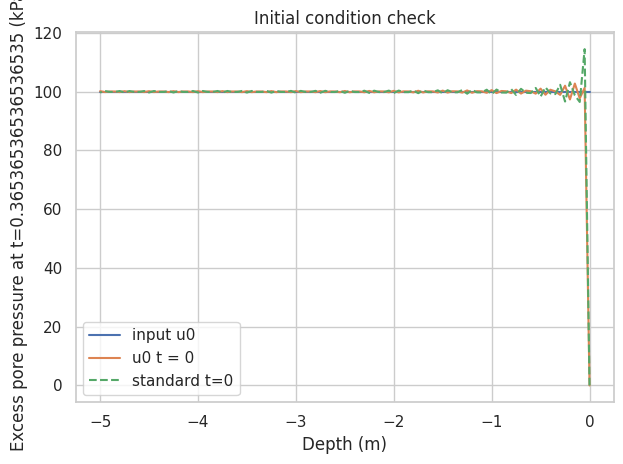

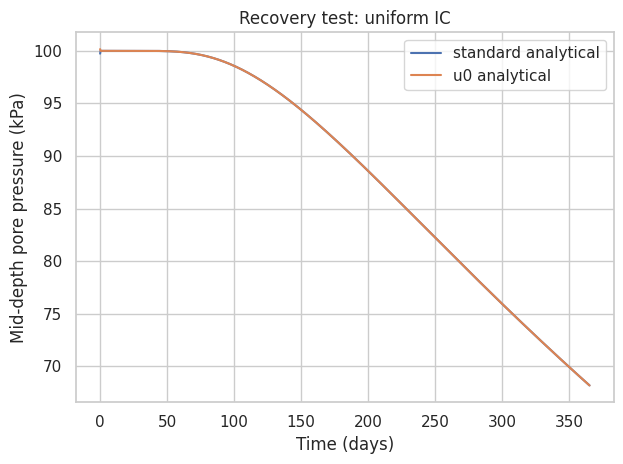

In [7]:

metrics_uniform = error_metrics(u_std, u_u0)
print('Uniform recovery metrics:', metrics_uniform)

plt.figure()
plt.plot(-depth, uniform_u0, label='input u0')
plt.plot(-depth,u_u0[0], label='u0 t = 0')
plt.plot(-depth_std, u_std[0], '--', label='standard t=0')
plt.xlabel('Depth (m)')
plt.ylabel(f'Excess pore pressure at t={time_std[1]} (kPa)')
plt.legend()
plt.title('Initial condition check')
plt.tight_layout()
plt.show()




plt.figure()
center = len(depth_std) // 2
plt.plot(time_std, u_std[:, -1], label='standard analytical')
plt.plot(time_std, u_u0[:, -1], label='u0 analytical')
plt.xlabel('Time (days)')
plt.ylabel('Mid-depth pore pressure (kPa)')
plt.legend()
plt.title('Recovery test: uniform IC')
plt.tight_layout()
plt.show()

## N-convergence Guide (Boussinesq `u₀`)

Compare solutions for increasing Fourier truncation counts and measure convergence to the finest retained case.

In [ ]:
boussinesq_u0 = boussinesq(depth, load, base=3.0)
n_values = [20, 40, 80, 120]
results = []
solutions = {}

for n in sorted(n_values):
    u_data, _, _ = Get_Terazaghi1d_Analytical_u0(boussinesq_u0, H, num, T, time_steps, Cv, n)
    solutions[n] = u_data
reference = solutions[max(n_values)]

for n in sorted(n_values):
    metrics = error_metrics(reference, solutions[n])
    metrics['n_terms'] = n
    results.append(metrics)

df_conv = pd.DataFrame(results).set_index('n_terms')
print(df_conv)

plt.figure()
plt.plot(df_conv.index, df_conv['rmse'], marker='o', label='RMSE')
plt.plot(df_conv.index, df_conv['max_abs'], marker='o', label='Max abs')
plt.plot(df_conv.index, df_conv['norm_l2'], marker='o', label='Norm L2')
plt.xlabel('N terms')
plt.ylabel('Error relative to N=160')
plt.legend()
plt.title('N-convergence metrics')
plt.tight_layout()
plt.show()

plt.figure()
mid = len(depth) // 2
for n in sorted(n_values):
    plt.plot(time, solutions[n][:, mid], label=f'N={n}')
plt.xlabel('Time (days)')
plt.ylabel('Mid-depth pore pressure (kPa)')
plt.title('Time evolution for different N')
plt.legend(title='Fourier count', fontsize='small')
plt.tight_layout()
plt.show()
